# 분석 단계별 프로세스 - 데이터 품질진단 + 순환 신경망(Simple RNN)

1. 라이브러리 / 데이터 불러오기
2. 데이터 종류 및 개수 확인
3. 데이터 품질지표 (KAMP 부록 4장: 완전성 / 유일성 / 유효성 / 일관성 / 정확성 / 무결성)
4. 데이터 정제(전처리) 및 저장
5. Simple RNN 피크전력(15분) 예측 — lag 피처, 훈련/테스트 분리, 모델 구축 및 훈련
6. 분석 시각화

## 1. 라이브러리 / 데이터 불러오기

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("../data/okm_augumented_2021.csv")
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(exist_ok=True)  # 결과물을 results/ 폴더에 정리 저장

df = pd.read_csv(DATA_PATH)

In [2]:
import platform

# 한글 폰트: macOS는 AppleGothic, Windows는 Malgun Gothic
plt.rcParams["font.family"] = "Malgun Gothic" if platform.system() == "Windows" else "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

## 2. 데이터 종류 및 개수 확인

In [3]:
n_rows, n_cols = df.shape
total_cells = n_rows * n_cols
print(f"[정보] 데이터 shape: {df.shape}  (전체 셀 수: {total_cells})")
df.info()
df.head()

[정보] 데이터 shape: (6168, 18)  (전체 셀 수: 111024)
<class 'pandas.DataFrame'>
RangeIndex: 6168 entries, 0 to 6167
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   날짜        6168 non-null   int64  
 1   시간        6168 non-null   int64  
 2   15분       6168 non-null   int64  
 3   30분       6168 non-null   int64  
 4   45분       6168 non-null   int64  
 5   60분       6168 non-null   int64  
 6   평균        6168 non-null   int64  
 7   생산량       6168 non-null   int64  
 8   기온        6168 non-null   float64
 9   풍속        6165 non-null   float64
 10  습도        6168 non-null   int64  
 11  강수량       6167 non-null   float64
 12  전기요금(계절)  6168 non-null   float64
 13  day       6168 non-null   int64  
 14  d         6168 non-null   int64  
 15  m         6168 non-null   int64  
 16  공장인원      6151 non-null   float64
 17  인건비       6168 non-null   float64
dtypes: float64(6), int64(12)
memory usage: 867.5 KB


,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.0,1.5
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.0,1.5
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.0,1.5
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.0,1.5
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.0,1.5


## 3. 데이터 품질지표 (KAMP 부록 4장)

가이드북이 공개한 산식:

| 지표 | 산식 |
| --- | --- |
| 완전성 | (1 - 결측치수/전체데이터수) x 100 |
| 유일성 | (유일한 데이터수/전체데이터수) x 100 |
| 유효성 | (유효범위를 만족하는 데이터수/전체데이터수) x 100 |
| 일관성 | (자료형이 일치하는 데이터수/전체데이터수) x 100 |
| 정확성 | 컬럼값이 서로 독립적이라 가이드북에서 측정하지 않음 |
| 무결성 | 위 지표들을 종합한 지표 (정확한 합산 공식은 코드로 공개되지 않음) |

가이드북 참고값: 완전성 99.68% → (결측치 보정 후) 100.00%, 유일성 99.69%, 유효성 100.00%, 일관성 100.00%

> **투명성 고지**: 무결성 지표는 가이드북 본문에 "위 지표를 종합한다"는 설명만 있고 정확한 계산식(가중합/단순평균/미달지표 개수 기반 등)은 공개되지 않았다.
> 여기서는 측정 가능한 4개 지표(완전성·유일성·유효성·일관성)의 **단순평균**을 무결성의 근사치로 계산하며, 이는 가이드북의 공식이 아니라 우리가 정한 합산 방식이다.

### 3-1. 완전성 (Completeness) = (1 - 결측치수/전체데이터수) x 100

In [4]:
missing_cells = df.isna().sum().sum()
completeness = (1 - missing_cells / total_cells) * 100
print(f"[1] 완전성: 결측치 {missing_cells}개 / 전체 {total_cells}개")
print(f"    완전성 지수 = {completeness:.2f}%")
df.isna().sum()[df.isna().sum() > 0]

[1] 완전성: 결측치 21개 / 전체 111024개
    완전성 지수 = 99.98%


풍속       3
강수량      1
공장인원    17
dtype: int64

### 3-2. 유일성 (Uniqueness) = (유일한 데이터수/전체데이터수) x 100

행 전체 기준 중복이 아닌 행의 비율

In [5]:
n_duplicate_rows = df.duplicated().sum()
n_unique_rows = n_rows - n_duplicate_rows
uniqueness = (n_unique_rows / n_rows) * 100
print(f"[2] 유일성: 중복 행 {n_duplicate_rows}개 / 전체 {n_rows}행")
print(f"    유일성 지수 = {uniqueness:.2f}%")

[2] 유일성: 중복 행 0개 / 전체 6168행
    유일성 지수 = 100.00%


### 3-3. 유효성 (Validity) = (유효범위를 만족하는 데이터수/전체데이터수) x 100

날짜(수집기간 2021-01-01 ~ 2021-09-14), 시간(0~23) 범위 검사

In [6]:
valid_date = df["날짜"].between(20210101, 20210914)
valid_hour = df["시간"].between(0, 23)
valid_rows = (valid_date & valid_hour).sum()
validity = (valid_rows / n_rows) * 100
print(f"[3] 유효성(보정 전): 날짜(20210101~20210914) & 시간(0~23) 범위 만족 {valid_rows}행 / {n_rows}행")
print(f"    유효성 지수(보정 전) = {validity:.2f}%")

[3] 유효성(보정 전): 날짜(20210101~20210914) & 시간(0~23) 범위 만족 6120행 / 6168행
    유효성 지수(보정 전) = 99.22%


#### 3-3-1. 이상치 보정: "시간" 컬럼 48건 (2021-07-13, 07-15) 재구성

두 날짜의 `시간` 값이 0~23 범위를 벗어나 있다. 하루 24행은 그대로 있고 앞뒤 날짜와 행 순서도 이어져 있으므로, 날짜별 등장 순서를 0~23시로 다시 채운다(행 삭제 없음).

In [7]:
# 두 날짜 모두 24행이 그대로 있고 앞뒤 날짜와 행 순서가 이어져 있어(진단 완료),
# 데이터 누락이 아니라 "시간" 값만 깨진 것으로 판단. 두 날짜 모두 생산량이
# 24시간 내내 0이라 순서 재구성에 무리가 없어, 날짜별 등장 순서를 0~23시로
# 다시 채운다(행 삭제 없이 보정).
anomaly_dates = df.loc[~df["시간"].between(0, 23), "날짜"].unique()
for d in anomaly_dates:
    idx = df.index[df["날짜"] == d]
    df.loc[idx, "시간"] = range(len(idx))

valid_hour_fixed = df["시간"].between(0, 23)
valid_rows_fixed = (valid_date & valid_hour_fixed).sum()
validity_fixed = (valid_rows_fixed / n_rows) * 100
print(f"[3-보정] '시간' 이상치 보정 대상 날짜: {list(anomaly_dates)}")
print(f"    유효성 지수(보정 후) = {validity_fixed:.2f}%  (보정 전 {validity:.2f}% -> 보정 후 {validity_fixed:.2f}%)")

[3-보정] '시간' 이상치 보정 대상 날짜: [np.int64(20210713), np.int64(20210715)]
    유효성 지수(보정 후) = 100.00%  (보정 전 99.22% -> 보정 후 100.00%)


### 3-4. 일관성 (Consistency) = (자료형이 일치하는 데이터수/전체데이터수) x 100

숫자형이어야 할 컬럼이 실제로 숫자로 파싱되는지 검사 (결측은 자료형 불일치로 보지 않음)

In [8]:
numeric_cols = [c for c in df.columns if c not in ["날짜", "시간"]]
consistent_cells = 0
checked_cells = 0
for c in numeric_cols:
    parsed = pd.to_numeric(df[c], errors="coerce")
    consistent_cells += parsed.notna().sum() + df[c].isna().sum()  # 결측은 자료형 불일치로 보지 않음
    checked_cells += len(df[c])
consistency = (consistent_cells / checked_cells) * 100
print(f"[4] 일관성: 숫자형 파싱 성공 {consistent_cells}개 / 검사대상 {checked_cells}개 (수치형 컬럼 {len(numeric_cols)}개)")
print(f"    일관성 지수 = {consistency:.2f}%")

[4] 일관성: 숫자형 파싱 성공 98688개 / 검사대상 98688개 (수치형 컬럼 16개)
    일관성 지수 = 100.00%


### 3-5. 정확성 (Accuracy)

해당 데이터셋은 컬럼값이 서로 독립적이라 가이드북과 동일하게 측정하지 않는다.

### 3-6. 무결성 (Integrity)

측정 가능한 4개 지표의 단순평균 (※ 우리 임의 정의, 가이드북 공식 아님). 유효성은 보정 후 값을 쓴다.

In [9]:
integrity = (completeness + uniqueness + validity_fixed + consistency) / 4
print(f"[6] 무결성(근사치, 단순평균, 보정 후 유효성 기준): {integrity:.2f}%")

[6] 무결성(근사치, 단순평균, 보정 후 유효성 기준): 100.00%


### 3-7. 가이드북 참고값 vs 재현 결과

In [10]:
quality_table = pd.DataFrame(
    {
        "가이드북 참고값": ["99.68~100%", "99.69%", "100.00%", "100.00%"],
        "보정 전(%)": [completeness, uniqueness, validity, consistency],
        "보정 후(%)": [completeness, uniqueness, validity_fixed, consistency],
    },
    index=["완전성", "유일성", "유효성", "일관성"],
).round(2)

with open(RESULTS_DIR / "quality_metrics.txt", "w") as f:
    f.write(f"completeness={completeness:.4f}\n")
    f.write(f"uniqueness={uniqueness:.4f}\n")
    f.write(f"validity_before_fix={validity:.4f}\n")
    f.write(f"validity_after_fix={validity_fixed:.4f}\n")
    f.write(f"consistency={consistency:.4f}\n")
    f.write(f"integrity_approx={integrity:.4f}\n")
    f.write(f"missing_cells={missing_cells}\n")
    f.write(f"duplicate_rows={n_duplicate_rows}\n")
    f.write(f"time_anomaly_dates={list(anomaly_dates)}\n")
    f.write(f"time_anomaly_rows_fixed={len(df.index[df['날짜'].isin(anomaly_dates)])}\n")

quality_table

,가이드북 참고값,보정 전(%),보정 후(%)
완전성,99.68~100%,99.98,99.98
유일성,99.69%,100.00,100.00
유효성,100.00%,99.22,100.00
일관성,100.00%,100.00,100.00


## 4. 데이터 정제(전처리) 및 저장

`시간` 보정(3-3-1)을 반영한 상태에서 결측치를 0으로 채워 `results/df_frame.csv`로 저장한다.
03~06 notebook은 이 파일을 읽는다. (02는 원본을 직접 읽어 자체 전처리를 한다.)

In [11]:
df_frame = df.fillna(0)
assert df_frame["시간"].between(0, 23).all()
df_frame.to_csv(RESULTS_DIR / "df_frame.csv", index=False)
df_frame.isna().sum().sum()

np.int64(0)

## 5. Simple RNN 기반 피크전력(15분) 예측

가이드북은 "15분 Peak Consumption"에 대해 t-1 ~ t-168(1주일치 시간별) lag를 피처로 만들고 MinMax 정규화 후 RNN에 넣어 예측했다.
정확한 레이어 구성은 가이드북에 공개돼 있지 않아, 여기서는 통상적인 Simple RNN 구조로 재현한다.

In [12]:
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

tf.random.set_seed(42)
np.random.seed(42)

N_LAGS = 168          # 1주일치 시간별 lag (가이드북과 동일)
TEST_HOURS = 336      # 9/1~9/14 (2주), 가이드북과 동일한 테스트 구간

### 5-1. lag 피처 생성 (결측 발생 구간은 제거)

In [13]:
series = df["15분"].astype(float).reset_index(drop=True)
print(f"[정보] 원계열 길이: {len(series)}")

lagged = pd.DataFrame({"y": series})
for lag in range(1, N_LAGS + 1):
    lagged[f"lag_{lag}"] = series.shift(lag)
lagged = lagged.dropna().reset_index(drop=True)
print(f"[정보] lag 피처 구성 후 shape: {lagged.shape}")

[정보] 원계열 길이: 6168
[정보] lag 피처 구성 후 shape: (6000, 169)


/var/folders/vf/znfb070j6k715nvznr4dfvn80000gn/T/ipykernel_70165/1656965421.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lagged[f"lag_{lag}"] = series.shift(lag)


### 5-2. 훈련/테스트 분리 (시간순, 뒤 336개를 테스트로) 및 정규화

스케일러는 train으로만 fit 한다.

In [14]:
train_df = lagged.iloc[:-TEST_HOURS]
test_df = lagged.iloc[-TEST_HOURS:]

feat_cols = [c for c in lagged.columns if c != "y"]
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = scaler_X.fit_transform(train_df[feat_cols])
X_test = scaler_X.transform(test_df[feat_cols])
y_train = scaler_y.fit_transform(train_df[["y"]])
y_test = scaler_y.transform(test_df[["y"]])

# RNN 입력 형태: (샘플, 168 타임스텝, 1 피처)
X_train_seq = X_train.reshape(-1, N_LAGS, 1)
X_test_seq = X_test.reshape(-1, N_LAGS, 1)

print(f"[정보] train={X_train_seq.shape}, test={X_test_seq.shape}")

[정보] train=(5664, 168, 1), test=(336, 168, 1)


### 5-3. Simple RNN 모델 구축 및 훈련

In [15]:
model = keras.Sequential([
    keras.layers.Input(shape=(N_LAGS, 1)),
    keras.layers.SimpleRNN(64, activation="tanh"),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(1),
])
model.compile(optimizer="adam", loss="mse")

early_stop = keras.callbacks.EarlyStopping(monitor="loss", patience=5, restore_best_weights=True)
history = model.fit(
    X_train_seq, y_train,
    epochs=60, batch_size=128,
    verbose=2, callbacks=[early_stop],
)

Epoch 1/60


45/45 - 1s - 21ms/step - loss: 0.0434


Epoch 2/60


45/45 - 0s - 10ms/step - loss: 0.0348


Epoch 3/60


...

45/45 - 0s - 10ms/step - loss: 0.0331


Epoch 37/60


45/45 - 0s - 11ms/step - loss: 0.0354


Epoch 38/60


45/45 - 0s - 10ms/step - loss: 0.0329


### 5-4. 예측 및 역정규화

In [16]:
pred_scaled = model.predict(X_test_seq, verbose=0)
pred = scaler_y.inverse_transform(pred_scaled).flatten()
actual = test_df["y"].values

test_mse = mean_squared_error(actual, pred)
print("=== 결과 ===")
print(f"test MSE (원단위): {test_mse:.4f}")
print(f"test RMSE (원단위): {np.sqrt(test_mse):.4f}")

result_df = pd.DataFrame({"actual_15min": actual, "forecast": pred})
result_df.to_csv(RESULTS_DIR / "rnn_forecast_result.csv", index=False)
with open(RESULTS_DIR / "rnn_metrics.txt", "w") as f:
    f.write(f"test_mse={test_mse:.4f}\ntest_rmse={np.sqrt(test_mse):.4f}\n")

=== 결과 ===
test MSE (원단위): 220.2229
test RMSE (원단위): 14.8399


## 6. 분석 시각화

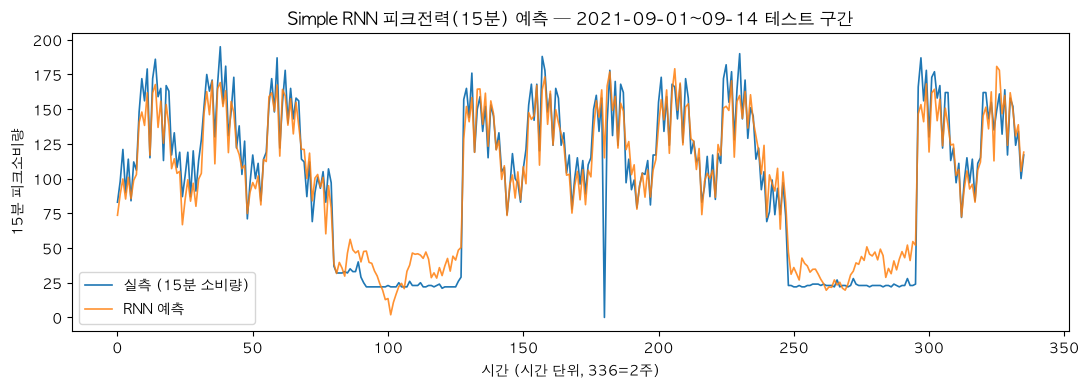

In [17]:
plt.figure(figsize=(11, 4))
plt.plot(actual, label="실측 (15분 소비량)", linewidth=1.2)
plt.plot(pred, label="RNN 예측", linewidth=1.2, alpha=0.85)
plt.title("Simple RNN 피크전력(15분) 예측 — 2021-09-01~09-14 테스트 구간")
plt.xlabel("시간 (시간 단위, 336=2주)")
plt.ylabel("15분 피크소비량")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "rnn_forecast_plot.png", dpi=130)
plt.show()